In [4]:
import os
import h5py
import numpy as np

# Import the function directly from your script
from Image_Model_comp_run import denoise_volume 

# 1. Define your target file and the list of models
target_file = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0001720320.h5'

# These are the models defined in your original Image_Model_comp_run.py script
models_to_run = [
    'scunet_trained', 
    'scunet_pre', 
    'scunet_ft', 
    'nature', 
    'CAE', 
    'CAE_3D', 
    'bm3d'
]

# --- Define output directory and create it if it doesn't exist ---
output_dir = "Denoised"
os.makedirs(output_dir, exist_ok=True)

# Extract the base filename once (e.g., "density_tot_vmc_mean_0001720320")
base_filename = os.path.splitext(os.path.basename(target_file))[0]

# Load the density array ONCE outside the loop to save time
print(f"Loading target file: {os.path.basename(target_file)}...")
with h5py.File(target_file, 'r') as file:
    test_density = file['density'][:]

# 2. Loop through the MODELS instead of the files
for model_name in models_to_run:
    print(f"\n--- Running model: {model_name} ---")
    
    # Create the safe relative path for this specific model
    output_filename = os.path.join(output_dir, f"{base_filename}_{model_name}_denoised.npy")
    
    try:
        # 3. Call the imported function
        denoised_array = denoise_volume(test_density, model_name)
        
        # Save the output
        print(f"Saving to {output_filename}...")
        np.save(output_filename, denoised_array)
        
    except Exception as e:
        # If one model fails (e.g. path issues or memory limits), this prevents the whole loop from crashing
        print(f"⚠️ Failed to run {model_name}. Error: {e}")
    
print("\nBatch processing complete!")

Loading target file: density_tot_vmc_mean_0001720320.h5...

--- Running model: scunet_trained ---
Saving to Denoised/density_tot_vmc_mean_0001720320_scunet_trained_denoised.npy...

--- Running model: scunet_pre ---
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, dr

I0000 00:00:1772040968.627204   52792 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
I0000 00:00:1772040968.628625   52792 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38479 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1772040968.629934   52792 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38479 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
I0000 00:00:1772040968.631358   52792 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38479 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0
I0000 00:00:1772040970.860570   56220 service.cc:152] XLA servic

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


I0000 00:00:1772040972.897169   56220 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Saving to Denoised/density_tot_vmc_mean_0001720320_nature_denoised.npy...

--- Running model: CAE ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step 
Saving to Denoised/density_tot_vmc_mean_0001720320_CAE_denoised.npy...

--- Running model: CAE_3D ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Saving to Denoised/density_tot_vmc_mean_0001720320_CAE_3D_denoised.npy...

--- Running model: bm3d ---
Saving to Denoised/density_tot_vmc_mean_0001720320_bm3d_denoised.npy...

Batch processing complete!


Loading reference and noisy files...


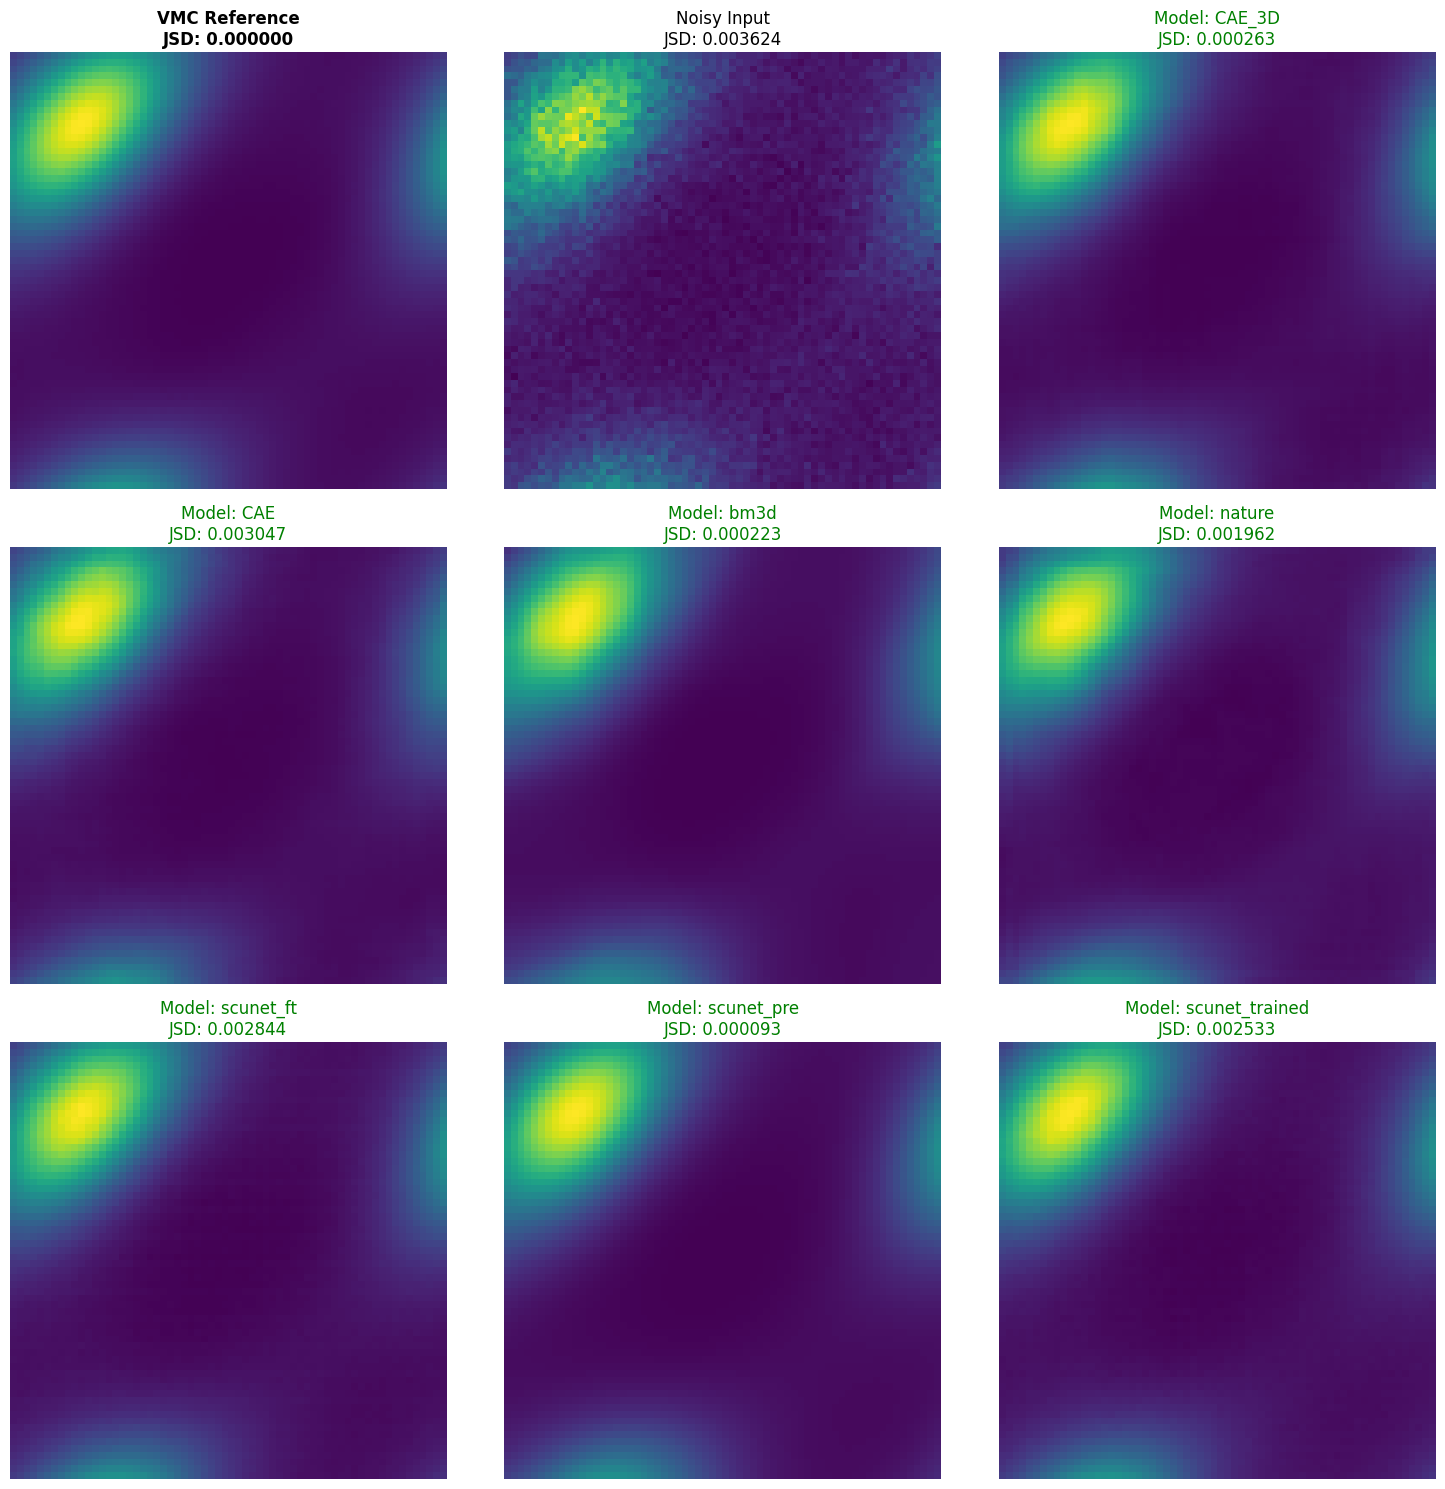

In [5]:
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Import the D_JS metric directly from your script
from Image_Model_comp_run import D_JS

# ==========================================
# 1. Configuration & Paths
# ==========================================
ref_path = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5'
noisy_path = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0001720320.h5'
denoised_dir = 'Denoised'

slice_idx = 32

# ==========================================
# 2. Load Data
# ==========================================
print("Loading reference and noisy files...")
with h5py.File(ref_path, 'r') as file:
    ref_density = file['density'][:]
    
with h5py.File(noisy_path, 'r') as file:
    noisy_density = file['density'][:]

# Find all denoised .npy files in the output directory
denoised_files = sorted(glob.glob(os.path.join(denoised_dir, '*.npy')))
base_filename = os.path.splitext(os.path.basename(noisy_path))[0]

# ==========================================
# 3. Setup Plot Grid & Calculate JSD
# ==========================================
# Total plots = 1 (Ref) + 1 (Noisy) + len(denoised_files)
num_plots = len(denoised_files) + 2 
cols = 3
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() # Flatten to loop easily

# --- Plot 1: Reference ---
axes[0].imshow(ref_density[slice_idx], cmap='viridis')
axes[0].set_title("VMC Reference\nJSD: 0.000000", fontsize=12, fontweight='bold')
axes[0].axis('off')

# --- Plot 2: Noisy Input ---
# Calling the imported D_JS function
jsd_noisy = D_JS(noisy_density, ref_density)
axes[1].imshow(noisy_density[slice_idx], cmap='viridis')
axes[1].set_title(f"Noisy Input\nJSD: {jsd_noisy:.6f}", fontsize=12)
axes[1].axis('off')

# --- Plots 3+: Denoised Models ---
for i, file_path in enumerate(denoised_files):
    # Extract the clean model name from the filename 
    model_name = os.path.basename(file_path).replace(f"{base_filename}_", "").replace("_denoised.npy", "")
    
    # Load the array and calculate metrics using the imported function
    denoised_density = np.load(file_path)
    jsd_val = D_JS(denoised_density, ref_density)
    
    # Plot
    ax = axes[i + 2]
    ax.imshow(denoised_density[slice_idx], cmap='viridis')
    
    # Highlight the title in green if it beats the noisy input, red if it's worse
    color = "green" if jsd_val < jsd_noisy else "red"
    ax.set_title(f"Model: {model_name}\nJSD: {jsd_val:.6f}", fontsize=12, color=color)
    ax.axis('off')

# Turn off any empty subplots at the end of the grid
for j in range(num_plots, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()